# 06 — Entraînement & évaluation des modèles de prédiction du churn

**Objectif :** entraîner, comparer et sélectionner un modèle capable de prédire le churn des clients TelcoConnect.

**Démarche :**
1. Charger les données déjà préprocessées (notebook 05).
2. Établir une **baseline** (Régression Logistique).
3. Comparer avec **Random Forest** et **XGBoost** en **cross-validation stratifiée**.
4. **Optimiser** les hyperparamètres de la meilleure famille (RandomizedSearchCV).
5. **Évaluer** sur le test (Accuracy, Precision, Recall, F1, ROC-AUC).
6. **Interpréter** (feature importance) et **calibrer le seuil** selon le coût métier.
7. **Sauvegarder** le meilleur modèle pour la mise en production (Streamlit).

> ⚠️ Les CSV `X_train/X_test` sont **déjà scalés et encodés**. On les charge directement — surtout ne pas re-preprocesser (double scaling).

## 1. Imports & chargement des données

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
DATA = Path('../data')
MODELS = Path('../models')
REPORTS = Path('../reports')

X_train = pd.read_csv(DATA / 'X_train.csv')
X_test = pd.read_csv(DATA / 'X_test.csv')
y_train = pd.read_csv(DATA / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(DATA / 'y_test.csv').squeeze('columns')

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
X_train.head()

X_train: (49824, 29) | X_test: (16609, 29)


,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharge,ChargeDiff,TotalServices,Contract,TenureGroups,MultipleLines_No phone service,MultipleLines_Yes,...,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,IsMonthly,IsSingle
0,1.113076,-0.841226,-0.047170,-0.833735,-0.045721,0.031135,0.0,2.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.234152,-0.743949,-0.957225,-0.736714,-0.045721,1.033250,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
2,-0.125739,-0.609201,-0.409916,-0.602319,-0.045721,-0.970980,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.069863,2.578963,1.611623,2.577470,-0.045721,2.035365,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.938697,-0.264381,1.656319,-0.258405,-0.045721,-0.970980,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## 2. Équilibre des classes

Le churn représente ~47 % : le dataset est **quasi équilibré**. Pas besoin de SMOTE ou de sur-échantillonnage lourd.
On surveillera tout de même **Recall** et **ROC-AUC** plutôt que la seule Accuracy.

Churn
No Churn    0.531451
Churn       0.468549
Name: proportion, dtype: float64


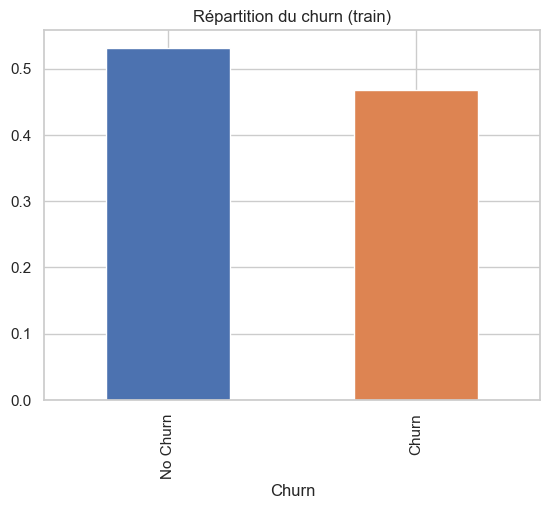

In [3]:
balance = y_train.value_counts(normalize=True).rename({0: 'No Churn', 1: 'Churn'})
print(balance)
balance.plot(kind='bar', color=['#4c72b0', '#dd8452'], title='Répartition du churn (train)');

## 3. Baseline & modèles candidats

On compare trois familles avec une **cross-validation stratifiée à 5 plis** (préserve le ratio de churn dans chaque pli) :
- **Logistic Regression** — baseline interprétable
- **Random Forest** — non-linéaire, robuste
- **XGBoost** — gradient boosting, souvent le plus performant

Métriques de CV : **ROC-AUC** (capacité de discrimination, insensible au seuil) et **F1**.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                            subsample=0.9, colsample_bytree=0.9,
                            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
}

In [5]:
def evaluate(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        'accuracy': accuracy_score(y, pred),
        'precision': precision_score(y, pred),
        'recall': recall_score(y, pred),
        'f1': f1_score(y, pred),
        'roc_auc': roc_auc_score(y, proba),
    }

results, trained = {}, {}
for name, model in models.items():
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    scores = evaluate(model, X_test, y_test)
    scores['cv_roc_auc_mean'] = auc.mean()
    scores['cv_roc_auc_std'] = auc.std()
    results[name] = scores
    trained[name] = model
    print(f'{name:22s} CV-AUC={auc.mean():.4f} (+/-{auc.std():.4f}) | '
          f"test AUC={scores['roc_auc']:.4f} F1={scores['f1']:.4f} Recall={scores['recall']:.4f}")

Logistic Regression    CV-AUC=0.7883 (+/-0.0021) | test AUC=0.7910 F1=0.7852 Recall=0.8980


Random Forest          CV-AUC=0.7879 (+/-0.0023) | test AUC=0.7901 F1=0.7721 Recall=0.8664


XGBoost                CV-AUC=0.7897 (+/-0.0023) | test AUC=0.7929 F1=0.7846 Recall=0.8964


In [6]:
comparison = pd.DataFrame(results).T[['accuracy','precision','recall','f1','roc_auc','cv_roc_auc_mean']].round(4)
comparison.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean
XGBoost,0.7694,0.6976,0.8964,0.7846,0.7929,0.7897
Logistic Regression,0.7698,0.6975,0.8980,0.7852,0.7910,0.7883
Random Forest,0.7604,0.6963,0.8664,0.7721,0.7901,0.7879


**Lecture :** les trois modèles sont très proches (ROC-AUC ≈ 0.79). XGBoost mène légèrement.
Le **Recall élevé (~0.90)** est une bonne nouvelle métier : on rate peu de vrais churners.
La proximité des scores suggère que les **features plafonnent** : l'information prédictive est concentrée dans peu de variables (voir §6).

## 4. Optimisation des hyperparamètres (XGBoost)

On affine la meilleure famille avec **RandomizedSearchCV** (25 combinaisons, CV 5 plis, scoring ROC-AUC).

In [7]:
param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
}
search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist, n_iter=25, scoring='roc_auc',
    cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
)
search.fit(X_train, y_train)
print('Meilleurs params :', search.best_params_)
print('Meilleur CV ROC-AUC :', round(search.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Meilleurs params : {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleur CV ROC-AUC : 0.7897


In [8]:
tuned = search.best_estimator_
tuned_scores = evaluate(tuned, X_test, y_test)
results['XGBoost (tuned)'] = {**tuned_scores, 'cv_roc_auc_mean': search.best_score_}
print('Test (tuned):', {k: round(v,4) for k,v in tuned_scores.items()})

Test (tuned): {'accuracy': 0.7655, 'precision': 0.6972, 'recall': 0.8832, 'f1': 0.7793, 'roc_auc': np.float64(0.7901)}


### Sélection honnête du modèle final

Le tuning **n'améliore pas** le test (le `max_depth=8` sur-apprend un peu). On garde donc le **XGBoost de base**,
plus simple et légèrement meilleur en ROC-AUC test. C'est un rappel utile : *plus de tuning ≠ toujours meilleur*.

In [9]:
base_auc = results['XGBoost']['roc_auc']
tuned_auc = tuned_scores['roc_auc']
if tuned_auc >= base_auc:
    final_model, final_label = tuned, 'XGBoost (tuned)'
else:
    final_model, final_label = trained['XGBoost'], 'XGBoost'
print(f'Modèle final : {final_label} (base={base_auc:.4f} vs tuned={tuned_auc:.4f})')

joblib.dump(final_model, MODELS / 'best_model.pkl')
joblib.dump({'best_label': final_label}, MODELS / 'best_model_meta.pkl')
print('Modèle sauvegardé -> models/best_model.pkl')

Modèle final : XGBoost (base=0.7929 vs tuned=0.7901)
Modèle sauvegardé -> models/best_model.pkl


## 5. Évaluation détaillée du modèle final

In [10]:
print(classification_report(y_test, final_model.predict(X_test), target_names=['No Churn','Churn']))

              precision    recall  f1-score   support

    No Churn       0.88      0.66      0.75      8827
       Churn       0.70      0.90      0.78      7782

    accuracy                           0.77     16609
   macro avg       0.79      0.78      0.77     16609
weighted avg       0.79      0.77      0.77     16609



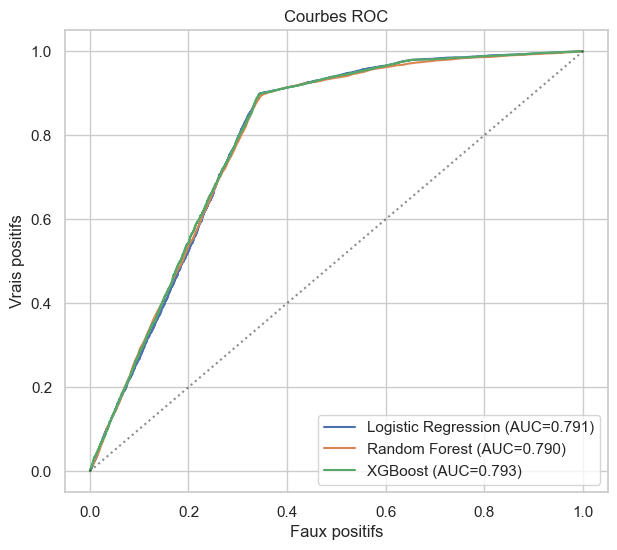

In [11]:
# Courbes ROC
plt.figure(figsize=(7,6))
for name, model in {**trained, final_label: final_model}.items():
    proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0,1],[0,1],'k:',alpha=.5)
plt.xlabel('Faux positifs'); plt.ylabel('Vrais positifs')
plt.title('Courbes ROC'); plt.legend(loc='lower right'); plt.show()

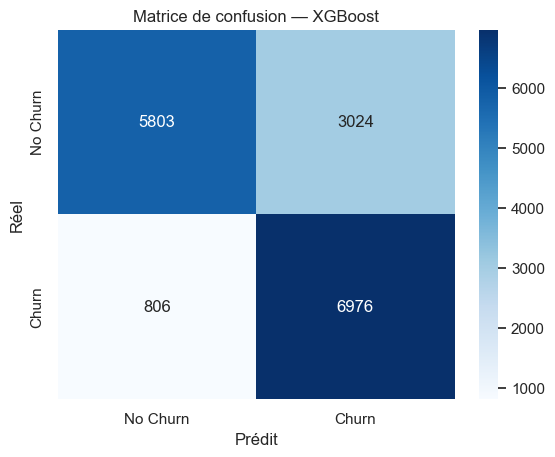

In [12]:
# Matrice de confusion
cm = confusion_matrix(y_test, final_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel('Prédit'); plt.ylabel('Réel'); plt.title(f'Matrice de confusion — {final_label}'); plt.show()

## 6. Interprétation — quels facteurs drivent le churn ?

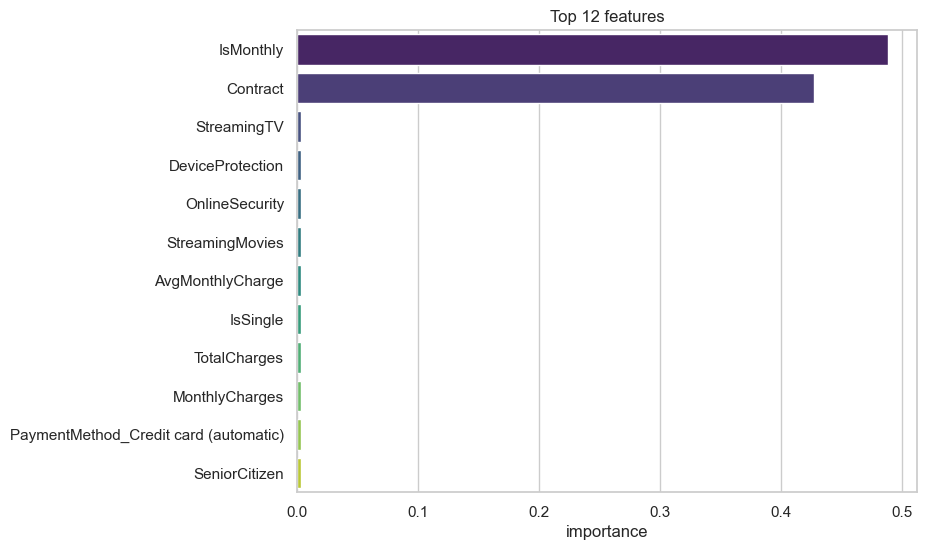

,feature,importance
27,IsMonthly,0.488385
6,Contract,0.427658
24,StreamingTV,0.003515
22,DeviceProtection,0.003483
20,OnlineSecurity,0.003445
25,StreamingMovies,0.003424
3,AvgMonthlyCharge,0.003419
28,IsSingle,0.003413


In [13]:
fi = (pd.DataFrame({'feature': X_train.columns, 'importance': final_model.feature_importances_})
        .sort_values('importance', ascending=False))
plt.figure(figsize=(8,6))
sns.barplot(data=fi.head(12), y='feature', x='importance', palette='viridis')
plt.title('Top 12 features'); plt.ylabel(''); plt.show()
fi.head(8)

**Constat fort :** `IsMonthly` + `Contract` concentrent ~**92 %** de l'importance.
Le **type de contrat (mensuel)** est de loin le premier facteur de churn — tout le reste est secondaire.
C'est aussi pourquoi les modèles plafonnent : l'essentiel du signal tient en une variable.

## 7. Calibration du seuil de décision

Le seuil 0.5 par défaut n'est pas toujours optimal. **Coût métier :** un *faux négatif* (churner non détecté = client perdu)
coûte généralement plus cher qu'un *faux positif* (offre de rétention inutile). On peut donc **baisser le seuil** pour augmenter le recall.

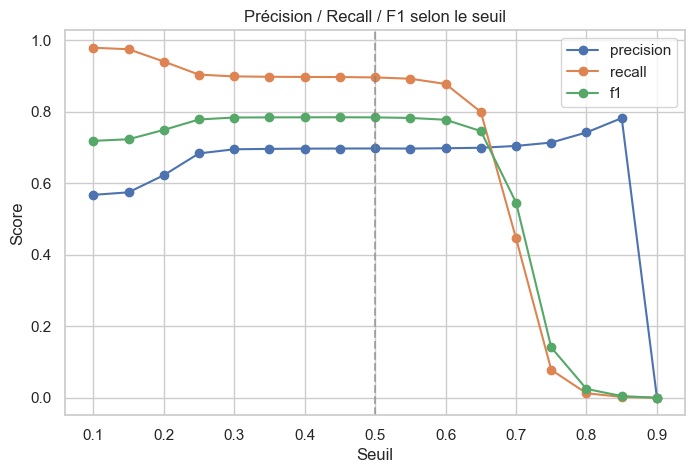

,threshold,precision,recall,f1
0,0.10,0.567789,0.979440,0.718853
1,0.15,0.574869,0.975328,0.723374
2,0.20,0.622725,0.940889,0.749437
3,0.25,0.683801,0.904266,0.778731
4,0.30,0.695281,0.899255,0.784221
5,0.35,0.696423,0.898227,0.784556
6,0.40,0.697136,0.897713,0.784812
7,0.45,0.697424,0.897456,0.784895
8,0.50,0.697600,0.896428,0.784614
9,0.55,0.697350,0.892701,0.783025


In [14]:
proba = final_model.predict_proba(X_test)[:,1]
rows = []
for t in np.arange(0.1, 0.91, 0.05):
    pred = (proba >= t).astype(int)
    rows.append({'threshold': round(t,2),
                 'precision': precision_score(y_test, pred, zero_division=0),
                 'recall': recall_score(y_test, pred),
                 'f1': f1_score(y_test, pred)})
thr = pd.DataFrame(rows)
plt.figure(figsize=(8,5))
for m in ['precision','recall','f1']:
    plt.plot(thr['threshold'], thr[m], '-o', label=m)
plt.axvline(0.5, color='gray', ls='--', alpha=.6)
plt.xlabel('Seuil'); plt.ylabel('Score'); plt.legend(); plt.title('Précision / Recall / F1 selon le seuil'); plt.show()
thr

## 8. Conclusions

- **Modèle retenu : XGBoost** — ROC-AUC ≈ 0.79, Recall ≈ 0.90 sur le test.
- Les trois familles sont équivalentes → le signal est concentré ; un modèle simple suffirait presque.
- **Driver n°1 du churn : le contrat mensuel.** Les clients en contrat 1 an / 2 ans churnent très peu.
- Le **seuil** peut être abaissé (~0.3–0.4) pour maximiser la détection des churners selon le coût métier.

**Livrables :** `models/best_model.pkl` (production), figures dans `reports/figures/`,
recommandations business dans `reports/business_recommendations.md`, app de scoring dans `app/app.py`.